In [16]:
# Initialize a model
from langchain_openai import ChatOpenAI

from dotenv import load_dotenv
load_dotenv()

llm = ChatOpenAI(model="gpt-4o", temperature=0, streaming=True)

In [27]:
from typing_extensions import TypedDict

# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str
    
# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""
    
    msg = llm.invoke(f"Write a short joke about {state["topic"]}")
    print(msg)
    
    return {"joke": msg.content}

joke =generate_joke({"topic": "dog"})

content="Why did the dog sit in the shade?  \n\nBecause he didn't want to be a hot dog!" additional_kwargs={} response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f33640a400', 'service_tier': 'default'} id='run--c6c8cdd6-4ee5-4951-8463-19ff0d333421-0'


In [28]:
def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""
    
    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"

check_punchline(joke)

'Pass'

In [29]:
def improve_joke(state: State):
    """Second LLM call to improve the joke"""
    
    msg = llm.invoke(f"Make this funnier by adding wordplay: {state['joke']}")

    return {"improved_joke": msg.content}

improved_joke = improve_joke(joke)

In [30]:
def polish_joke(state: State):
    """Third LLM call for final polish"""

    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    print(msg)
    return {"final_joke": msg.content}

final_joke = polish_joke(improved_joke)

content="Why did the dog sit in the shade?  \n\nBecause he didn't want to be a hot dog—he was already a little ruff around the edges! But then he realized he was actually sitting on a treasure map leading to a hidden stash of bacon!" additional_kwargs={} response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f33640a400', 'service_tier': 'default'} id='run--3b9f5c87-f2e8-49a3-bb89-3214aa65d480-0'


In [33]:
from langgraph.graph import StateGraph, START, END

# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges("generate_joke", check_punchline, {"Fail": "improve_joke", "Pass":END})
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

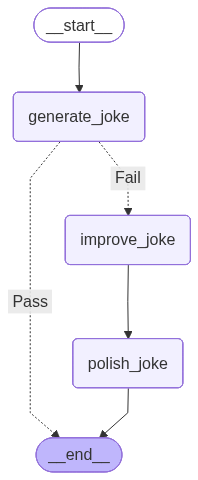

In [34]:
from IPython.display import Image, display

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))


In [35]:
# Invoke
state = chain.invoke({"topic": "cat"})
print("Initial Joke: ")
print(state["joke"])
print("\n-----------------------------\n")
if "improved_joke" in state:
    print("Improved Joke: ")
    print(state["improved_joke"])
    print("\n-----------------------------\n")
    
    print("Final Joke: ")
    print(state["final_joke"])
else:
    print("Joke failed quality gate - no punchline detected.")

content='Why was the cat sitting on the computer? \n\nBecause it wanted to keep an eye on the mouse!' additional_kwargs={} response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f33640a400', 'service_tier': 'default'} id='run--f4116406-1eed-4d69-a5cd-03433f07601c-0'
Initial Joke: 
Why was the cat sitting on the computer? 

Because it wanted to keep an eye on the mouse!

-----------------------------

Joke failed quality gate - no punchline detected.
